In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import cloudpickle
import torch
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.crn_text_parser import reactions_from_text

import sys
sys.path.append('../..')


## Solver and Plotting

In [2]:
solver = 'CVODE'
ATOL = 1e-10
RTOL = 1e-10

# Plot concentration/output levels on either 'linear' or 'log' scale.
level_scale = 'linear'


def apply_level_scale(ax):
    if level_scale not in {'linear', 'log'}:
        raise ValueError("level_scale must be either 'linear' or 'log'.")
    ax.set_yscale(level_scale)


## Load the learned CRN

In [3]:
# checkpoint_path = repo_root / 'apps' / 'RPA_task_chkpt.pkl'
# hof_index = 0  # best hall-of-fame entry retaining all three species

# _original_torch_load = torch.load
# def torch_load_cpu(*args, **kwargs):
#     kwargs.setdefault('map_location', torch.device('cpu'))
#     return _original_torch_load(*args, **kwargs)

# torch.load = torch_load_cpu
# with checkpoint_path.open('rb') as handle:
#     checkpoint = cloudpickle.load(handle)
# torch.load = _original_torch_load

# iocrn = checkpoint['hall_of_fame_crns'][hof_index].clone()
# iocrn.reset()
# iocrn.solver = 'CVODE'
# iocrn.atol = 1e-10
# iocrn.rtol = 1e-10

# print('Checkpoint epoch:', checkpoint['epoch'])
# print('Hall-of-fame index:', hof_index)
# print(iocrn)

## Build the CRN

In [4]:
# reactions = [
#     MassAction([], ["X_1"], input_channels=["u_1"], params=[1.0], params_controllability=[False]),
#     MassAction(["X_1"], ["X_4", "X_4"], params=[0.04084748402237892]),
#     MassAction(["X_4"], ["X_1"], params=[0.04595428705215454]),
#     MassAction(["X_1", "X_1"], ["X_3", "X_4"], params=[0.048695046454668045]),
#     MassAction(["X_1", "X_2"], ["X_2"], params=[0.6668475270271301]),
#     MassAction(["X_1", "X_4"], ["X_2", "X_3"], params=[0.04605919495224953]),
#     MassAction(["X_2", "X_2"], [], params=[0.05097213387489319]),
#     MassAction(["X_3", "X_4"], ["X_1"], params=[0.05004750192165375]),
#     MassAction(["X_4", "X_4"], ["X_2", "X_4"], params=[0.04662628099322319]),
# ]

reaction_text = """
CRN hof_0, Reward: 0.0033397777268518525 
Inputs: ['u_1'] 
Species: ['X_1', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> X_3;  [MAK(1.0442190170288086)]
X_1 + X_1 ----> X_1 + X_3;  [MAK(0.9667757749557495)]
X_1 + X_1 ----> X_3 + X_3;  [MAK(0.9543337821960449)]
X_3 + X_3 ----> X_3;  [MAK(0.999956488609314)]
"""

reactions = reactions_from_text(reaction_text)

iocrn = IOCRN(reactions, output_labels=['X_3'], solver=solver, atol=ATOL, rtol=RTOL)
iocrn.compile()
print(iocrn)

Inputs: ['u_1'] 
Species: ['X_1', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> X_3;  [MAK(1.0442190170288086)]
X_1 + X_1 ----> X_1 + X_3;  [MAK(0.9667757749557495)]
X_1 + X_1 ----> X_3 + X_3;  [MAK(0.9543337821960449)]
X_3 + X_3 ----> X_3;  [MAK(0.999956488609314)]


## Simulate the input range

In [5]:
u_values = np.linspace(0.0, 1.0, 101, dtype=np.float32)
u_list = [np.array([u], dtype=np.float32) for u in u_values]
time_horizon = np.linspace(0.0, 100.0, 600, dtype=np.float32)
x0 = np.full(iocrn.num_species, 0.01, dtype=np.float32)

time, states, outputs, _ = iocrn.transient_response(
    u_list, [x0], time_horizon, force=True
)
final_output = np.array([np.asarray(y)[0, -1] for y in outputs])
target_output = np.sqrt(u_values)

## Dose response

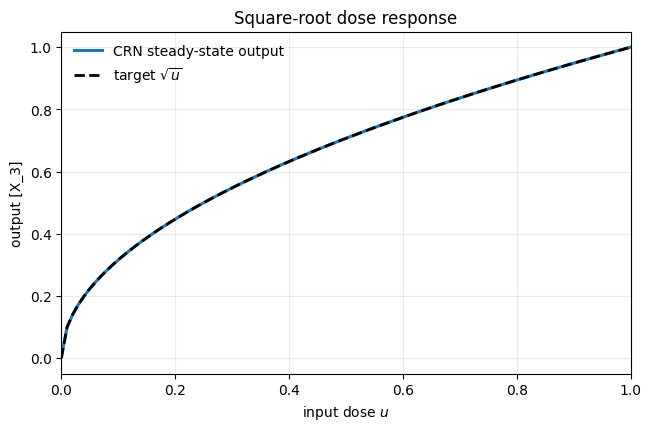

In [8]:
fig_dose, ax = plt.subplots(figsize=(6.4, 4.2), constrained_layout=True)
ax.plot(u_values, final_output, color='C0', linewidth=2.2, label='CRN steady-state output')
ax.plot(u_values, target_output, 'k--', linewidth=2.0, label=r'target $\sqrt{u}$')
ax.set(xlabel='input dose $u$', ylabel=f'output [{iocrn.output_labels[0]}]',
       title='Square-root dose response')
ax.set_xlim(0, 1)
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig_dose.savefig('sqrt_3S_4R-1_dose_response.pdf', bbox_inches='tight')
plt.show()

## Time dynamics

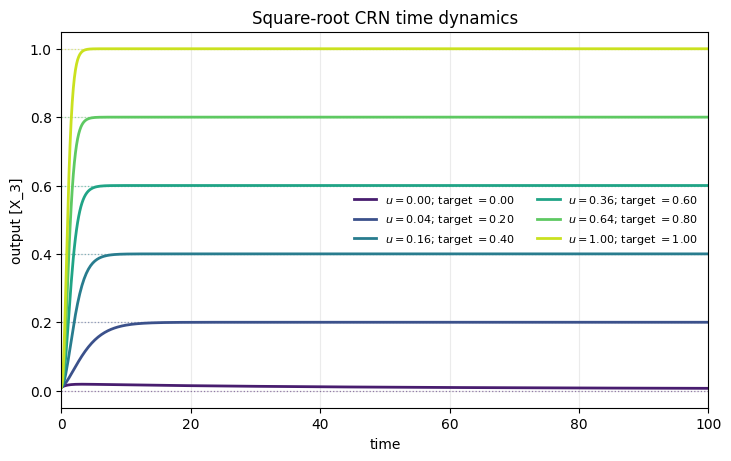

In [7]:
selected_doses = np.array([0.0, 0.04, 0.16, 0.36, 0.64, 1.0])
selected_indices = [int(np.argmin(np.abs(u_values - u))) for u in selected_doses]
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(selected_indices)))

fig_time, ax = plt.subplots(figsize=(7.2, 4.5), constrained_layout=True)
for idx, color in zip(selected_indices, colors):
    dose = float(u_values[idx])
    trajectory = np.asarray(outputs[idx])[0]
    ax.plot(time, trajectory, color=color, linewidth=2.0,
            label=fr'$u={dose:.2f}$; target $={np.sqrt(dose):.2f}$')
    ax.axhline(np.sqrt(dose), color=color, linestyle=':', linewidth=0.9, alpha=0.55)

ax.set(xlabel='time', ylabel=f'output [{iocrn.output_labels[0]}]',
       title='Square-root CRN time dynamics')
ax.set_xlim(time[0], time[-1])
ax.legend(frameon=False, ncol=2, fontsize=8)
ax.grid(alpha=0.25)
fig_time.savefig('sqrt_3S_4R-1_time_dynamics.pdf', bbox_inches='tight')
plt.show()